# **1. Perkenalan Dataset**


Dataset yang digunakan pada proyek ini adalah **Machine Predictive Maintenance Classification Dataset**.

Dataset ini berisi data sensor industri yang digunakan untuk melakukan prediksi kerusakan mesin (*predictive maintenance*). Dataset terdiri dari 10.000 data dengan beberapa parameter operasional mesin seperti temperatur udara, temperatur proses, kecepatan rotasi, torsi, dan tingkat keausan alat.

Dalam industri Oil and Gas maupun manufaktur, predictive maintenance sangat penting untuk mengurangi downtime, meningkatkan efisiensi operasional, dan mencegah kerusakan mesin secara tiba-tiba.

## Tujuan Analisis
Proyek ini bertujuan untuk:
- Memahami karakteristik data sensor industri
- Melakukan preprocessing data sebelum pemodelan machine learning
- Menyiapkan dataset untuk klasifikasi kondisi machine failure

## Informasi Dataset
Dataset memiliki beberapa fitur utama, antara lain:
- Air Temperature
- Process Temperature
- Rotational Speed
- Torque
- Tool Wear
- Machine Failure (target)

Sumber dataset:
- Kaggle


# **2. Import Library**

In [1]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Setting style visualisasi
sns.set(style='whitegrid')

# **3. Memuat Dataset**

Pada tahap ini dilakukan proses pembacaan dataset ke dalam notebook menggunakan library pandas. Setelah dataset berhasil dimuat, dilakukan pengecekan struktur data untuk memastikan data siap digunakan pada tahap analisis dan preprocessing.

Dataset diperoleh dari platform Kaggle dan dimuat langsung menggunakan library kagglehub.

In [3]:
!pip install kagglehub

In [4]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "shivamb/machine-predictive-maintenance-classification"
)

print("Path to dataset files:", path)

100%|██████████| 137k/137k [00:00<00:00, 29.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/machine-predictive-maintenance-classification/versions/1


In [5]:
import os

os.listdir(path)

['predictive_maintenance.csv']

In [6]:
df = pd.read_csv(path + '/predictive_maintenance.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# **4. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum masuk ke tahap preprocessing dan modeling machine learning.

Pada tahap ini dilakukan beberapa analisis seperti:
- Mengecek missing value
- Mengecek data duplikat
- Melihat distribusi target
- Memahami distribusi fitur numerik
- Menganalisis hubungan antar fitur

In [7]:
# Ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (10000, 10)


In [8]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


Berdasarkan informasi dataset, terlihat bahwa dataset memiliki beberapa fitur numerik dan kategorikal yang akan digunakan untuk proses analisis dan preprocessing lebih lanjut.

In [9]:
# Statistik deskriptif
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


Statistik deskriptif digunakan untuk memahami distribusi data seperti nilai rata-rata, standar deviasi, nilai minimum, dan maksimum pada setiap fitur numerik.

In [10]:
# Mengecek missing value
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


Hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value sehingga data dapat langsung digunakan untuk tahap analisis berikutnya.

In [11]:
# Mengecek data duplikat
df.duplicated().sum()

np.int64(0)

Pemeriksaan data duplikat dilakukan untuk memastikan tidak terdapat data yang berulang dan dapat mempengaruhi performa model machine learning.

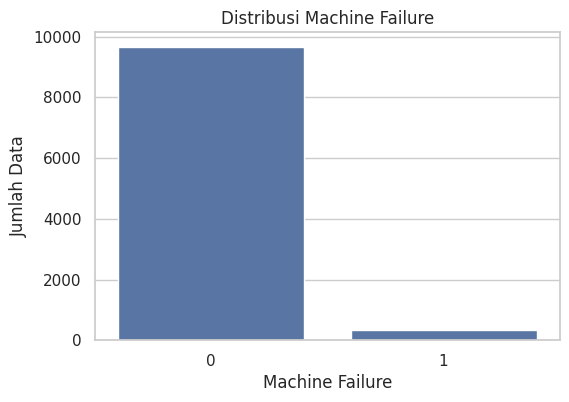

In [12]:
# Distribusi target
plt.figure(figsize=(6,4))

sns.countplot(
    x='Target',
    data=df
)

plt.title('Distribusi Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Jumlah Data')

plt.show()

Visualisasi distribusi target digunakan untuk melihat perbandingan jumlah kondisi normal dan machine failure pada dataset.

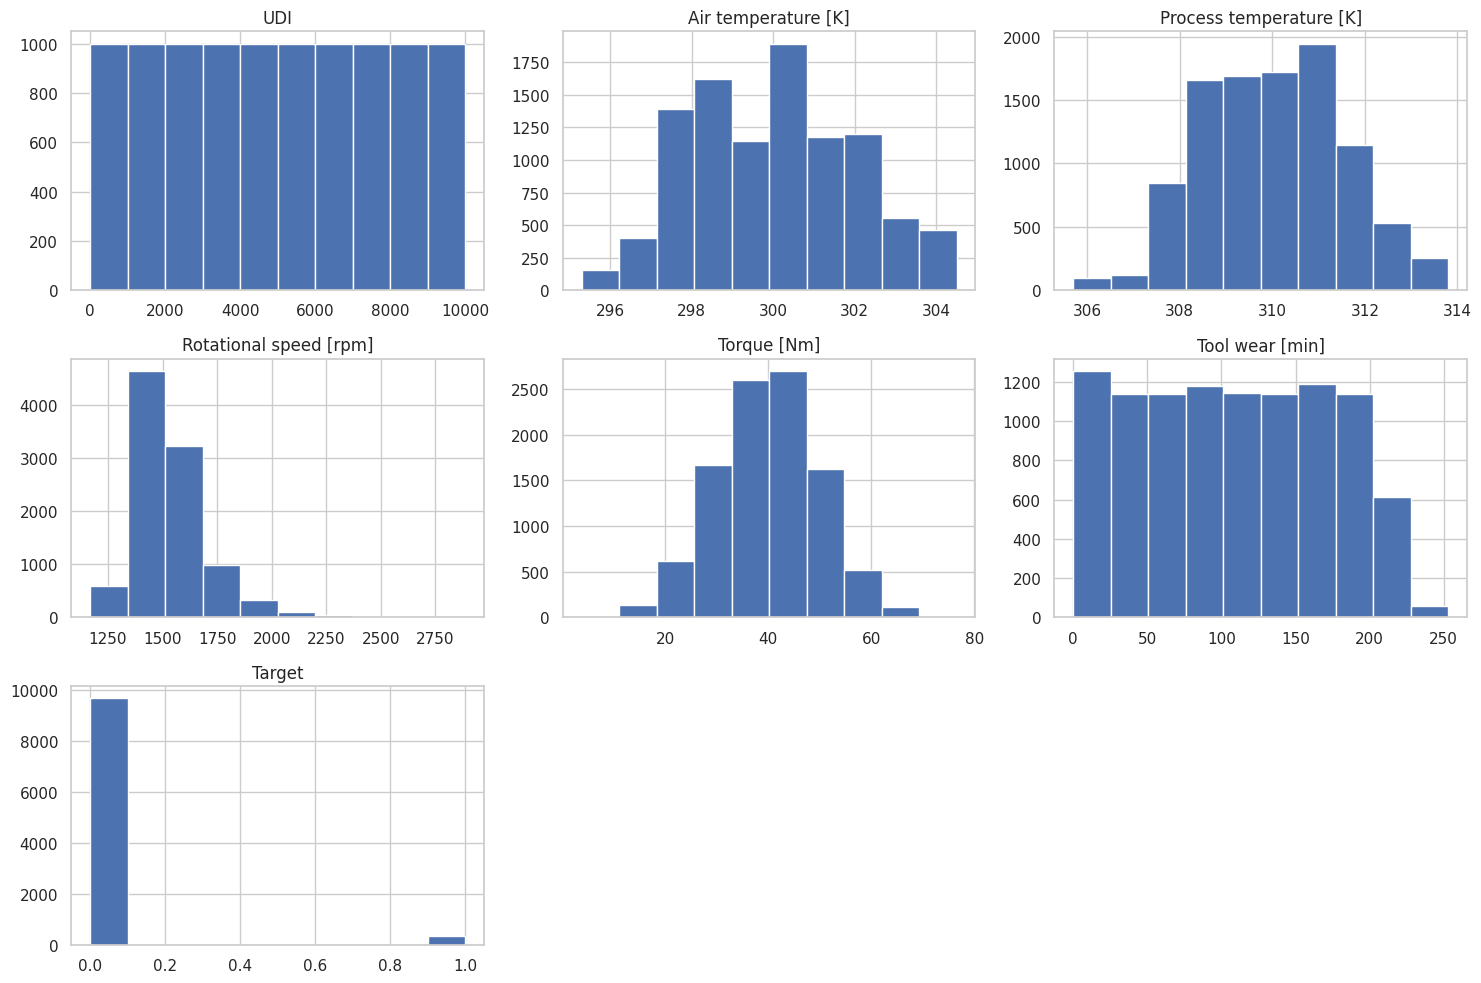

In [13]:
# Histogram fitur numerik
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

Histogram digunakan untuk memahami distribusi masing-masing fitur numerik pada dataset.

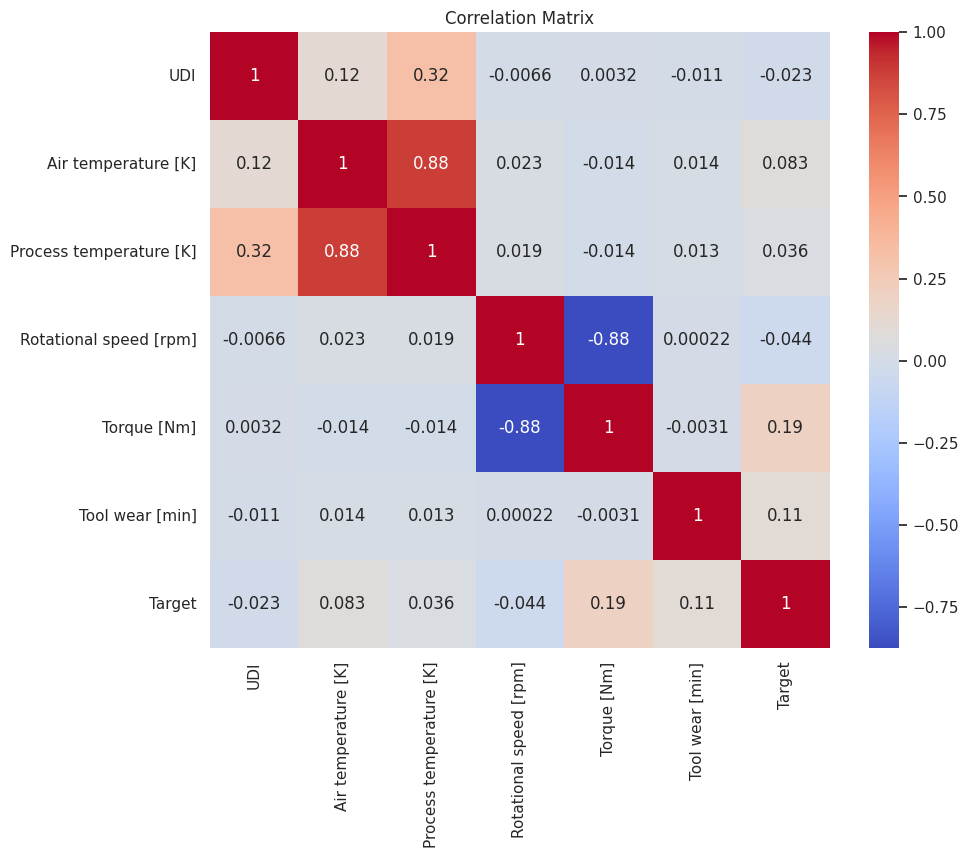

In [14]:
# Korelasi antar fitur numerik
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik dalam dataset.

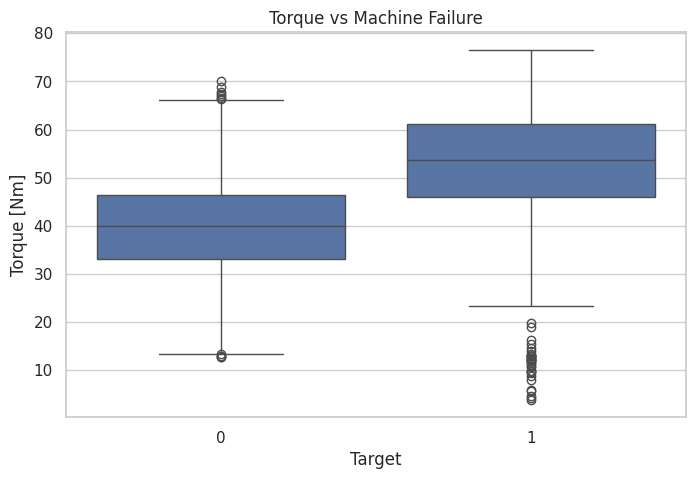

In [15]:
# Visualisasi torque terhadap machine failure
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Torque [Nm]',
    data=df
)

plt.title('Torque vs Machine Failure')

plt.show()

Boxplot digunakan untuk melihat perbedaan distribusi nilai torque terhadap kondisi machine failure.

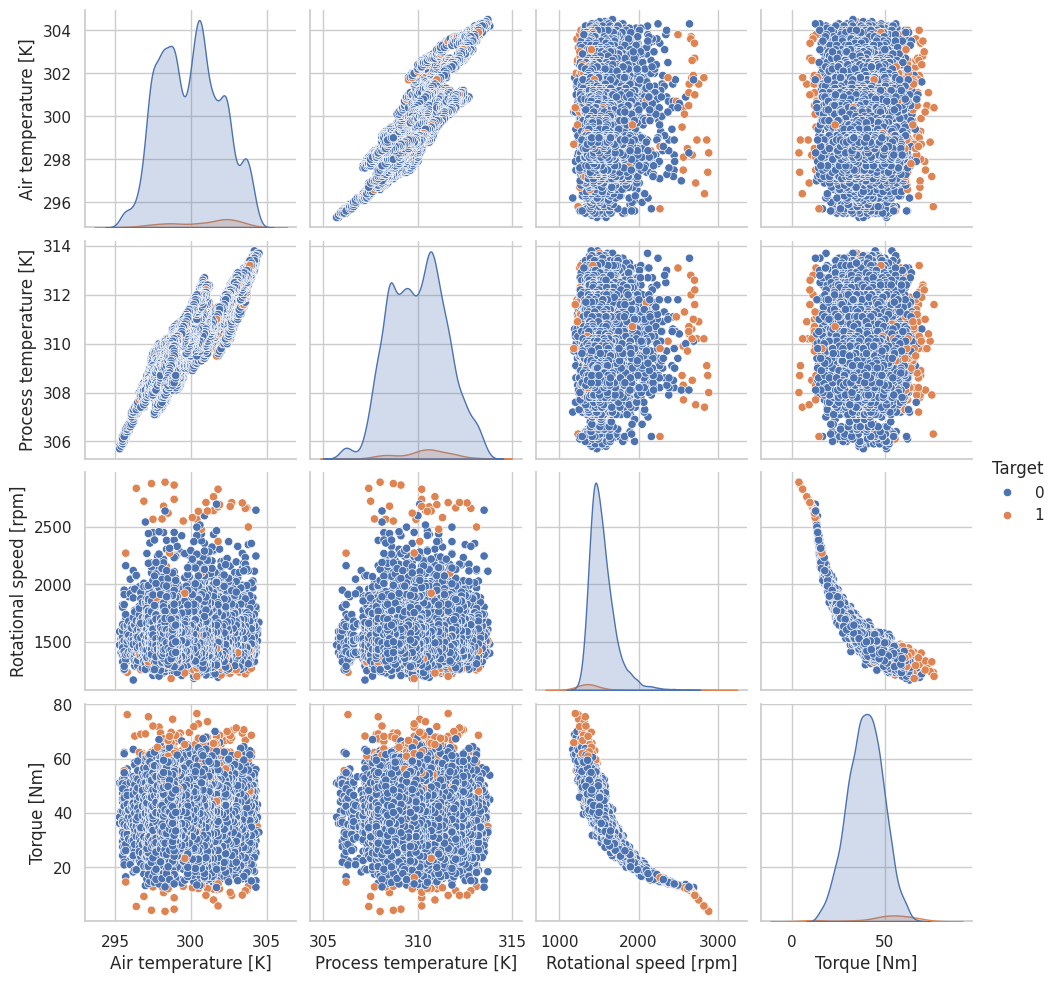

In [16]:
# Pairplot beberapa fitur penting
sns.pairplot(
    df[
        [
            'Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Target'
        ]
    ],
    hue='Target'
)

plt.show()

# **5. Data Preprocessing**

Tahap preprocessing dilakukan untuk membersihkan dan menyiapkan data sebelum digunakan pada proses machine learning.

Pada tahap ini dilakukan beberapa proses seperti:
- Menghapus fitur yang tidak diperlukan
- Encoding data kategorikal
- Memisahkan fitur dan target
- Membagi data training dan testing
- Normalisasi fitur numerik

In [17]:
# Melihat nama kolom
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [18]:
# Menghapus kolom Failure Type
df = df.drop('Failure Type', axis=1)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [24]:
# Menghapus Product ID
df = df.drop('Product ID', axis=1)

df.head()

,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,2,298.1,308.6,1551,42.8,0,0
1,2,1,298.2,308.7,1408,46.3,3,0
2,3,1,298.1,308.5,1498,49.4,5,0
3,4,1,298.2,308.6,1433,39.5,7,0
4,5,1,298.2,308.7,1408,40.0,9,0


In [26]:
# Encoding fitur kategorikal
le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])

df.head()

,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,2,298.1,308.6,1551,42.8,0,0
1,2,1,298.2,308.7,1408,46.3,3,0
2,3,1,298.1,308.5,1498,49.4,5,0
3,4,1,298.2,308.6,1433,39.5,7,0
4,5,1,298.2,308.7,1408,40.0,9,0


In [27]:
# Memisahkan fitur dan target
X = df.drop('Target', axis=1)
y = df['Target']

In [28]:
# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# Normalisasi fitur numerik
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# Menampilkan hasil scaling
X_train[:5]

array([[ 1.4692775 , -0.33656929, -0.85406604, -0.60958879,  0.42763418,
        -0.89269644,  1.37503539],
       [-1.19499359, -0.33656929, -0.90401361, -1.08052803, -0.83494457,
         1.38218727,  0.45762016],
       [-1.15724427, -0.33656929, -0.90401361, -1.48419023, -0.05967692,
        -0.89269644,  1.35921788],
       [ 0.37246916,  1.32550129,  0.44457086,  0.53412078,  0.33349453,
        -0.70228767, -1.59865535],
       [ 0.57402977, -0.33656929,  0.69430873,  0.33228968,  0.178441  ,
        -0.61209404,  1.58066294]])

## Kesimpulan Data Preprocessing

Berdasarkan proses preprocessing yang telah dilakukan, dataset berhasil dipersiapkan untuk tahap modeling machine learning.

Tahapan preprocessing meliputi:
- Menghapus kolom yang tidak relevan seperti `UDI`, `Product ID`, dan `Failure Type`
- Mengubah data kategorikal pada fitur `Type` menjadi data numerik menggunakan `LabelEncoder`
- Memisahkan dataset menjadi fitur (`X`) dan target (`y`)
- Membagi dataset menjadi data training dan testing menggunakan `train_test_split`
- Melakukan normalisasi fitur numerik menggunakan `StandardScaler`

Setelah preprocessing selesai, seluruh fitur telah berada dalam format numerik dan siap digunakan untuk proses pelatihan model machine learning pada tahap selanjutnya.

In [34]:
import os

os.listdir(path)

['predictive_maintenance.csv']

In [35]:
import shutil
import os

# Membuat folder raw dataset
os.makedirs('machine_predictive_maintenance_raw', exist_ok=True)

# Copy dataset
shutil.copy(
    path + '/predictive_maintenance.csv',
    'machine_predictive_maintenance_raw/predictive_maintenance.csv'
)

'machine_predictive_maintenance_raw/predictive_maintenance.csv'

In [36]:
import os

# Membuat folder preprocessing
os.makedirs(
    'machine_predictive_maintenance_preprocessing',
    exist_ok=True
)

# Simpan hasil preprocessing
pd.DataFrame(X_train).to_csv(
    'machine_predictive_maintenance_preprocessing/X_train.csv',
    index=False
)

pd.DataFrame(X_test).to_csv(
    'machine_predictive_maintenance_preprocessing/X_test.csv',
    index=False
)

pd.DataFrame(y_train).to_csv(
    'machine_predictive_maintenance_preprocessing/y_train.csv',
    index=False
)

pd.DataFrame(y_test).to_csv(
    'machine_predictive_maintenance_preprocessing/y_test.csv',
    index=False
)

In [37]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
kagglehub

Writing requirements.txt


In [38]:
%%writefile README.md

# Machine Predictive Maintenance Classification

## Deskripsi Project
Project ini bertujuan untuk melakukan preprocessing data pada dataset predictive maintenance menggunakan machine learning.

Dataset berisi data sensor industri seperti:
- Air Temperature
- Process Temperature
- Rotational Speed
- Torque
- Tool Wear

Target dari dataset adalah memprediksi kondisi machine failure.

## Tahapan Project
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing

## Tools dan Library
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Struktur Repository
```text
Eksperimen_SML_RezaFahlefi/
│
├── machine_predictive_maintenance_raw/
├── preprocessing/
├── machine_predictive_maintenance_preprocessing/
├── requirements.txt
└── README.md

Writing README.md
